# **Cats vs Dogs Image Classification using SVM**

## **Import Libraries**

In [35]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

!pip install scikit-image -q

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## **Dataset Upload**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving catsanddogs.zip to catsanddogs (1).zip


## **Extract Dataset**

In [ ]:
import zipfile

with zipfile.ZipFile('catsanddogs.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


## **Dataset Structure Verification**

In [ ]:
print("Dataset Structure")
print("-"*50)

for root, dirs, files in os.walk('/content/dataset'):
    print(root)

Dataset Structure
--------------------------------------------------
/content/dataset
/content/dataset/PetImages
/content/dataset/PetImages/Cat
/content/dataset/PetImages/Dog


## **Exploratory Data Analysis (EDA)**

In [ ]:
import os

cat_path = "/content/dataset/PetImages/Cat"
dog_path = "/content/dataset/PetImages/Dog"

print("Cats :", len(os.listdir(cat_path)))
print("Dogs :", len(os.listdir(dog_path)))

Cats : 12499
Dogs : 12499


## **Class Distribution**

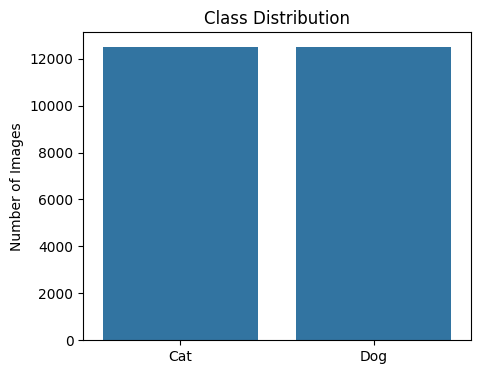

In [40]:
labels = ['Cat', 'Dog']
counts = [len(os.listdir(cat_path)), len(os.listdir(dog_path))]

plt.figure(figsize=(5,4))
sns.barplot(x=labels, y=counts)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

## **Data Quality Check**

In [ ]:
from PIL import Image

cat_path = "/content/dataset/PetImages/Cat"
dog_path = "/content/dataset/PetImages/Dog"

bad_images = []

for folder in [cat_path, dog_path]:

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        try:
            img = Image.open(img_path)
            img.verify()

        except:
            bad_images.append(img_path)

print("Corrupted Images Found :", len(bad_images))

Corrupted Images Found : 0


## **Dataset Visualization**

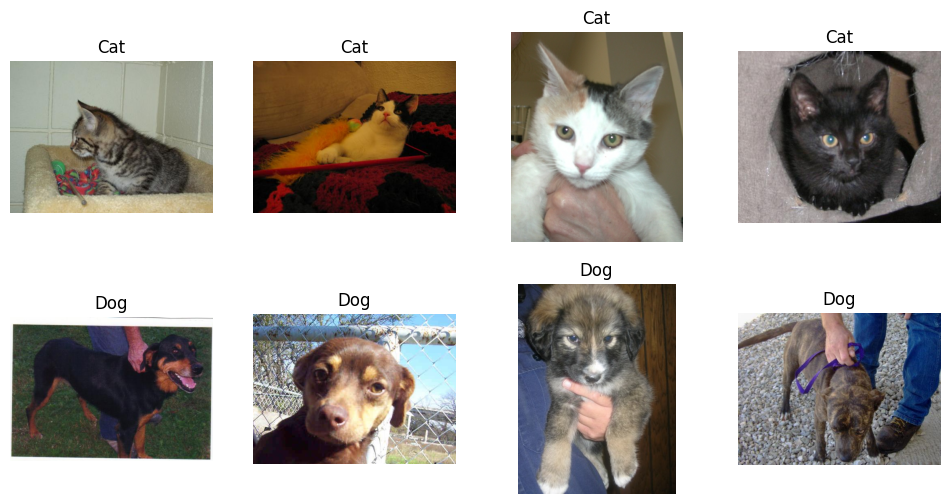

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

plt.figure(figsize=(12,6))

for i in range(4):

    img_name = random.choice(os.listdir(cat_path))

    img = cv2.imread(os.path.join(cat_path,img_name))
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title("Cat")
    plt.axis("off")

for i in range(4):

    img_name = random.choice(os.listdir(dog_path))

    img = cv2.imread(os.path.join(dog_path,img_name))
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,i+5)
    plt.imshow(img)
    plt.title("Dog")
    plt.axis("off")

plt.show()

##**Dataset Sampling**

In [ ]:
cat_path = "/content/dataset/PetImages/Cat"
dog_path = "/content/dataset/PetImages/Dog"

cat_images = random.sample(os.listdir(cat_path), 2000)
dog_images = random.sample(os.listdir(dog_path), 2000)

print("Selected Cats :", len(cat_images))
print("Selected Dogs :", len(dog_images))

Selected Cats : 2000
Selected Dogs : 2000


##**Image Preprocessing and HOG Feature Extraction**

In [ ]:
IMG_SIZE = 96

def extract_hog_features(image_path):

    image = cv2.imread(image_path)

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    features = hog(
    gray,
    orientations=12,
    pixels_per_cell=(8,8),
    cells_per_block=(3,3),
    block_norm='L2-Hys'
)

    return features

## **Feature Matrix Creation**

In [ ]:
X = []
y = []

In [ ]:
for img_name in cat_images:

    img_path = os.path.join(cat_path, img_name)

    try:

        features = extract_hog_features(img_path)

        X.append(features)

        y.append(0)

    except:
        pass

In [ ]:
for img_name in dog_images:

    img_path = os.path.join(dog_path, img_name)

    try:

        features = extract_hog_features(img_path)

        X.append(features)

        y.append(1)

    except:
        pass

In [37]:
X = np.array(X)
y = np.array(y)

print("Feature Matrix Shape :", X.shape)
print("Label Vector Shape :", y.shape)

Feature Matrix Shape : (4000, 10800)
Label Vector Shape : (4000,)


##**Feature Extraction Summary**

• Total Images Used: 4000
• Classes: Cat and Dog
• HOG Feature Length: 10800
• Feature Matrix Shape: (4000, 10800)

## **Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (3200, 10800)
Testing Set  : (800, 10800)


## **Feature Scaling**

In [48]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


## **Support Vector Machine (SVM) Training**

In [49]:
best_model = SVC(
    kernel='rbf',
    C=50,
    gamma='scale'
)

best_model.fit(X_train_scaled, y_train)

print("SVM Model Training Completed Successfully")
print("Kernel :", best_model.kernel)
print("C Value :", best_model.C)
print("Gamma :", best_model.gamma)


SVM Model Training Completed Successfully
Kernel : rbf
C Value : 50
Gamma : scale


##**Model Evaluation**

In [39]:
y_pred = best_model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"\nFinal Test Accuracy : {accuracy*100:.2f}%")


Final Test Accuracy : 74.75%


## **Classification Report**

In [ ]:
from sklearn.metrics import classification_report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.74      0.75       400
           1       0.75      0.75      0.75       400

    accuracy                           0.75       800
   macro avg       0.75      0.75      0.75       800
weighted avg       0.75      0.75      0.75       800



## **Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[298 102]
 [100 300]]


## **Confusion Matrix Visualization**

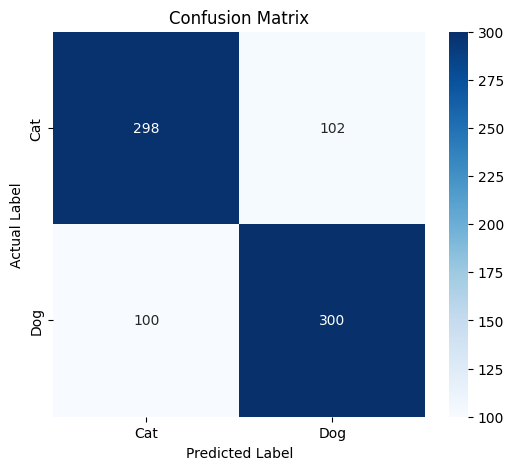

In [38]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cat', 'Dog'],
    yticklabels=['Cat', 'Dog']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()